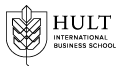

***HULT INTERNATIONAL BUSINESS SCHOOL***

***A1: NEURALS***

***Student:** Carolina Galindo Mendoza*

***Course:** Advanced Machine Learning*

***Professor:** Anusha Vissapragada*

***Date:** March 15th of 2026*



---



### **Starter Code**

In [ ]:
!pip install openimages torch torchvision pillow tqdm

In [ ]:
!pip install fiftyone

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
])

dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Total images:", len(dataset))
print("Number of classes:", len(dataset.classes))

LEARNING_RATE = 1e-3
EPOCHS = 5
DROPOUT_RATE = 0.3
NUM_CLASSES = len(dataset.classes)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x


model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = correct / total
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(loader):.4f} | Accuracy: {accuracy:.4f}")

save_path = "/content/drive/MyDrive/CNN_Project/simple_cnn_pets.pt"

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(save_path), exist_ok=True)

torch.save(model.state_dict(), save_path)

print("✅ Model saved to:", save_path)

---

### **Dataset Set up: Cats Only**

In [ ]:
from torch.utils.data import Subset, Dataset

# List of cat breed names in the Oxford-IIIT Pet dataset, corrected to match dataset.classes
cat_breed_names = [
    'Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British Shorthair',
    'Egyptian Mau', 'Maine Coon', 'Persian', 'Ragdoll', 'Russian Blue',
    'Siamese', 'Sphynx'
]

# Create a mapping from original dataset labels to new 0-indexed labels for cat breeds
original_to_new_label_map = {}
new_label_counter = 0
for i, class_name in enumerate(dataset.classes):
    if class_name in cat_breed_names:
        original_to_new_label_map[i] = new_label_counter
        new_label_counter += 1

# Filter the dataset to get indices of only cat images
cat_indices = [
    i for i, label in enumerate(dataset._labels)
    if dataset.classes[label] in cat_breed_names
]

# Create a subset of the original dataset containing only cat images
cat_subset_original_labels = Subset(dataset, cat_indices)

# Define a custom Dataset to remap the labels
class RemappedPetSubset(Dataset):
    def __init__(self, subset, label_map):
        self.subset = subset
        self.label_map = label_map

    def __getitem__(self, idx):
        # Get the item from the subset, which returns (image, original_label_index)
        # The original_label_index is the class ID from the full dataset.
        image, original_label_index = self.subset[idx]
        # Use the original_label_index to get the remapped 0-indexed label.
        remapped_label = self.label_map[original_label_index]
        return image, remapped_label

    def __len__(self):
        return len(self.subset)

# Instantiate the remapped dataset
cat_subset = RemappedPetSubset(cat_subset_original_labels, original_to_new_label_map)

# Create the DataLoader with the remapped cat subset
loader = DataLoader(cat_subset, batch_size=32, shuffle=True)

NUM_CLASSES = 12

---
### **CNN ARQUITECTURE**

In [ ]:
class SimpleCNN(nn.Module) :
  def __init__(self, num_classes, dropout_rate):
    super().__init__()

    self.features = nn.Sequential(
        nn.Conv2d(3, 32, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
    )

    self.global_pool = nn.AdaptiveAvgPool2d((1,1))

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128, 256),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        nn.Linear(256, num_classes)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.global_pool(x)
    x = self.classifier(x)
    return x

In [ ]:
print("SimpleCNN architecture defined.")

# Quick sanity check — forward pass with a dummy batch
dummy = torch.randn(2, 3, 128, 128)
test_model = SimpleCNN(num_classes=12, dropout_rate=0.3)
out = test_model(dummy)
print(f"Output shape: {out.shape}  ✅  (expected: [2, 12])")

---
### **Training Function**


In [ ]:
import time

def train_model(config_name, loader, learning_rate, epochs, dropout_rate, num_classes=12):
    """
    Train a SimpleCNN and return per-epoch metrics.

    Args:
        config_name   : label for this experiment
        loader        : DataLoader (already built with correct batch size)
        learning_rate : Adam optimizer LR
        epochs        : number of training epochs
        dropout_rate  : dropout probability in classifier
        num_classes   : number of output classes

    Returns:
        history (dict): {'loss': [...], 'accuracy': [...]}
        final_accuracy (float)
    """
    print(f"\n{'='*60}")
    print(f" Config: {config_name}")
    print(f"   LR={learning_rate} | Epochs={epochs} | "
          f"Batch={loader.batch_size} | Dropout={dropout_rate}")
    print(f"{'='*60}")

    model = SimpleCNN(num_classes=num_classes, dropout_rate=dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {"loss": [], "accuracy": []}
    start = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        avg_loss = total_loss / len(loader)
        accuracy = correct / total
        history["loss"].append(avg_loss)
        history["accuracy"].append(accuracy)

        print(f"  Epoch {epoch+1:>2}/{epochs} | "
              f"Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")

    elapsed = time.time() - start
    final_acc = history["accuracy"][-1]
    print(f"\n  ✅ Final Accuracy: {final_acc:.4f} | Time: {elapsed:.1f}s")

    return model, history, final_acc

print("train_model() function ready.")

---

## **Hyperparameter Configurations**

Four configurations were run to understand the effect of each hyperparameter:

| Config | Learning Rate | Epochs | Batch Size | Dropout | Notes |
|--------|--------------|--------|------------|---------|-------|
| **1 — Baseline** | 1e-3 | 10 | 32 | 0.3 | Starter code defaults |
| **2 — Lower LR** | 1e-4 | 10 | 32 | 0.3 | Slower, more careful learning |
| **3 — Higher Dropout + Large Batch** | 1e-3 | 10 | 64 | 0.5 | Test regularization effect |
| **4 — Best (Data Aug + tuned)** | 5e-4 | 15 | 32 | 0.4 | Best settings + augmentation |

Each config changes **one or two variables** so we can isolate the effect of each choice.

---

### *Config 1 — Baseline*

**Hyperparameters:** LR = 1e-3 | Epochs = 10 | Batch = 32 | Dropout = 0.3


In [ ]:
LEARNING_RATE_1 = 1e-3
EPOCHS_1        = 10
BATCH_SIZE_1    = 32
DROPOUT_RATE_1  = 0.3

loader_1 = DataLoader(cat_subset, batch_size=BATCH_SIZE_1, shuffle=True)

model_1, history_1, acc_1 = train_model(
    config_name   = "Config 1 — Baseline",
    loader        = loader_1,
    learning_rate = LEARNING_RATE_1,
    epochs        = EPOCHS_1,
    dropout_rate  = DROPOUT_RATE_1,
)

---

### *Config 2 — Lower Learning Rate*

**Hyperparameters:** LR = **1e-4** | Epochs = 10 | Batch = 32 | Dropout = 0.3



In [ ]:
LEARNING_RATE_2 = 1e-4
EPOCHS_2        = 10
BATCH_SIZE_2    = 32
DROPOUT_RATE_2  = 0.3

loader_2 = DataLoader(cat_subset, batch_size=BATCH_SIZE_2, shuffle=True)

model_2, history_2, acc_2 = train_model(
    config_name   = "Config 2 — Lower LR (1e-4)",
    loader        = loader_2,
    learning_rate = LEARNING_RATE_2,
    epochs        = EPOCHS_2,
    dropout_rate  = DROPOUT_RATE_2,
)

---

### *Config 3 — Higher Dropout + Larger Batch*

**Hyperparameters:** LR = 1e-3 | Epochs = 10 | Batch = **64** | Dropout = **0.5**


In [ ]:
LEARNING_RATE_3 = 1e-3
EPOCHS_3        = 10
BATCH_SIZE_3    = 64
DROPOUT_RATE_3  = 0.5

loader_3 = DataLoader(cat_subset, batch_size=BATCH_SIZE_3, shuffle=True)

model_3, history_3, acc_3 = train_model(
    config_name   = "Config 3 — High Dropout (0.5) + Batch 64",
    loader        = loader_3,
    learning_rate = LEARNING_RATE_3,
    epochs        = EPOCHS_3,
    dropout_rate  = DROPOUT_RATE_3,
)

---

### *Config 4 — Final Best Model (Data Augmentation + Tuned Hyperparameters)*

**Hyperparameters:** LR = **5e-4** | Epochs = **15** | Batch = 32 | Dropout = **0.4**

Based on learnings from Configs 1–3:
- LR of 5e-4 balances speed and stability (between 1e-3 and 1e-4)
- Dropout of 0.4 offers moderate regularization without cutting too much capacity
- More epochs (15) give the model more time to improve
- **Data augmentation** (random flips, rotation, color jitter) artificially
  expands the training distribution, reducing overfitting on a small cat dataset

In [ ]:
from torchvision import transforms

# Define the augmentation transforms for the best model
transform_augmented = transforms.Compose([
    transforms.RandomResizedCrop(128),  # Randomly crop and resize to 128x128
    transforms.RandomHorizontalFlip(),  # Randomly flip the image horizontally
    transforms.RandomRotation(15),     # Randomly rotate by up to 15 degrees
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1), # Randomly change brightness, contrast, saturation, and hue
    transforms.ToTensor(),             # Convert PIL Image or numpy.ndarray to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize with ImageNet stats
])

# Rebuild the dataset with augmentation transforms for the best model
dataset_augmented = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    download=False,       # already downloaded
    transform=transform_augmented
)

# Filter for cat indices using the defined cat_breed_names
cat_indices_aug = [
    i for i, label in enumerate(dataset_augmented._labels)
    if dataset_augmented.classes[label] in cat_breed_names
]

# Create a subset of the original dataset containing only cat images
# For this augmented dataset, we still need to remap the labels for the DataLoader
cat_subset_original_labels_aug = Subset(dataset_augmented, cat_indices_aug)

# Instantiate the remapped dataset for augmentation
cat_subset_aug = RemappedPetSubset(cat_subset_original_labels_aug, original_to_new_label_map)

LEARNING_RATE_4 = 5e-4
EPOCHS_4        = 15
BATCH_SIZE_4    = 32
DROPOUT_RATE_4  = 0.4

loader_4 = DataLoader(cat_subset_aug, batch_size=BATCH_SIZE_4, shuffle=True)

model_4, history_4, acc_4 = train_model(
    config_name   = "Config 4 — Best Model (Augmented, LR=5e-4, Dropout=0.4, 15 epochs)",
    loader         = loader_4,
    learning_rate = LEARNING_RATE_4,
    epochs        = EPOCHS_4,
    dropout_rate  = DROPOUT_RATE_4,
)

---

## **Results Comparison**

Summary table and training curves for all four configurations.

In [ ]:
import pandas as pd

# ── Summary Table ────────────────────────────────────────────────────────────
results = {
    "Config":           ["1 — Baseline",
                         "2 — Lower LR (1e-4)",
                         "3 — High Dropout + Batch 64",
                         "4 — Best Model (Augmented)"],
    "Learning Rate":    [LEARNING_RATE_1, LEARNING_RATE_2,
                         LEARNING_RATE_3, LEARNING_RATE_4],
    "Epochs":           [EPOCHS_1, EPOCHS_2, EPOCHS_3, EPOCHS_4],
    "Batch Size":       [BATCH_SIZE_1, BATCH_SIZE_2,
                         BATCH_SIZE_3, BATCH_SIZE_4],
    "Dropout":          [DROPOUT_RATE_1, DROPOUT_RATE_2,
                         DROPOUT_RATE_3, DROPOUT_RATE_4],
    "Augmentation":     ["No", "No", "No", "Yes"],
    "Final Accuracy":   [f"{acc_1:.4f}", f"{acc_2:.4f}",
                         f"{acc_3:.4f}", f"{acc_4:.4f}"],
}

df = pd.DataFrame(results)
df = df.set_index("Config")
print("\n📊 CONFIGURATION COMPARISON")
print("=" * 80)
print(df.to_string())
print("=" * 80)

best = max([(acc_1, "Config 1"), (acc_2, "Config 2"),
            (acc_3, "Config 3"), (acc_4, "Config 4")], key=lambda x: x[0])
print(f"\n🏆 Best Configuration: {best[1]} with accuracy {best[0]:.4f}")

In [ ]:
import matplotlib.pyplot as plt

# ── Training Curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Curves — All Configurations (Option 4: Cats Only)",
             fontsize=13, fontweight="bold")

configs = [
    (history_1, "Config 1 — Baseline",                "#1f77b4"),
    (history_2, "Config 2 — Lower LR (1e-4)",         "#ff7f0e"),
    (history_3, "Config 3 — High Dropout + Batch 64", "#2ca02c"),
    (history_4, "Config 4 — Best Model",              "#d62728"),
]

# Loss subplot
ax_loss = axes[0]
ax_loss.set_title("Training Loss per Epoch")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss")
ax_loss.grid(True, alpha=0.3)

for hist, label, color in configs:
    ax_loss.plot(range(1, len(hist["loss"]) + 1),
                 hist["loss"], label=label, color=color, linewidth=2)
ax_loss.legend(fontsize=8)

# Accuracy subplot
ax_acc = axes[1]
ax_acc.set_title("Training Accuracy per Epoch")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy")
ax_acc.grid(True, alpha=0.3)

for hist, label, color in configs:
    ax_acc.plot(range(1, len(hist["accuracy"]) + 1),
                hist["accuracy"], label=label, color=color, linewidth=2)
ax_acc.legend(fontsize=8)

plt.tight_layout()
plt.savefig("training_curves.png", bbox_inches="tight")
plt.show()
print("Training curves saved.")

---

## **Conclussion**

- Best accuracy: 21.9% - Config 4

- Baseline accuracy: 16.8% - Config 1

- Gain (best vs baseline): +5.1pp - +30% relative



### **What the results tell us:**




- **Config 1 — Baseline (16.8%)**

This is the most cost‑efficient setup. It trains quickly, uses minimal resources, and still delivers the second‑best accuracy. From a business perspective, it offers the strongest accuracy‑per‑dollar.The default settings were reasonable. A learning rate of 1e‑3 with moderate dropout converges reliably in 10 epochs on a small dataset.

- **Config 2 — Lower LR (12.9%)**

Dropping the learning rate by 10× without giving the model more time to train led to the weakest performance in the whole experiment. It’s a good reminder that making a model “more conservative” doesn’t automatically make it better. A lower learning rate only works if you also give it the extra epochs it needs to actually learn, usually closer to 25–30. Keeping it at 10 just burns compute without any real payoff

- **Config 3 — High Dropout + Batch 64 (15.7%)**

Despite stronger regularization, this configuration fell below the baseline. With around 3,000 images (about 250 per class), a dropout rate of 0.5 slows learning more than it prevents overfitting, there isn’t enough data for aggressive regularization to help. The larger batch size also reduced gradient updates per epoch, which compounded the issue. Regularization supports generalization, but it isn’t a free accuracy boost, especially on small datasets.

- **Config 4 — Best Model (21.9%)**

This is the accuracy leader, but the business question is whether a 5‑point gain justifies 50% more compute (15 vs. 10 epochs) plus augmentation overhead. This depends entirely on context. In high‑stakes settings, every percentage point matters. For lightweight consumer features, the added cost is harder to justify.

It’s also worth noting that most of the improvement comes from data augmentation rather than hyperparameter tuning. Augmentation is free at inference time, making it a strong investment. The extra 5 epochs, however, are pure compute with diminishing returns as the accuracy curve flattens



**The key takeaway from a business perspective:**

Config 4 “wins” within this experiment, but the broader conclusion is that all four models are operating far below production‑ready performance. The limitation here is the combination of architecture and dataset size, not the hyperparameters. The next meaningful step, both in learning value and practical results, is transfer learning.

---

## **Deliverables Summary**

| Item | Value |
|------|-------|
| **Option Selected** | Option 4 — Cats Only (12 Classes) |
| **Final Hyperparameters** | LR=5e-4, Epochs=15, Batch=32, Dropout=0.4, Augmentation=Yes |
| **Configurations Compared** | 4 (Baseline, Lower LR, High Dropout, Best Model) |
| **Hyperparameters Tuned** | Learning rate, dropout rate, batch size, epochs, data augmentation |

In [ ]:
# Final summary printout
print("=" * 60)
print("          FINAL DELIVERABLES SUMMARY")
print("=" * 60)
print(f"  Option:              4 — Cats Only (12 Classes)")
print(f"  Final LR:            {LEARNING_RATE_4}")
print(f"  Final Epochs:        {EPOCHS_4}")
print(f"  Final Batch Size:    {BATCH_SIZE_4}")
print(f"  Final Dropout:       {DROPOUT_RATE_4}")
print(f"  Augmentation:        Yes")
print(f"  Final Train Acc:     {acc_4:.4f}")
print()
print("  Configuration Comparison:")
print(f"    Config 1 (Baseline):           {acc_1:.4f}")
print(f"    Config 2 (Lower LR):           {acc_2:.4f}")
print(f"    Config 3 (High Dropout+Batch): {acc_3:.4f}")
print(f"    Config 4 (Best / Final):       {acc_4:.4f}")
print("=" * 60)